## Cat vs Dog Classifier — ResNet18
We use a pretrained ResNet18 and fine-tune it on our cat vs dog dataset. Images are resized to **224x224** which is what ResNet18 expects.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from PIL import Image

## 1. Load Dataset


In [2]:
TRAIN_DIR = 'cat_dog/train'
TEST_DIR = 'cat_dog/test'
IMG_SIZE = (224, 224)
CLASSES = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
print('Classes:', CLASSES)

mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
all_imgs, all_labels = [], []
for cls_idx, cls in enumerate(CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    for fname in sorted(os.listdir(cls_path)):
        if not fname.lower().endswith(('.jpg','.jpeg','.png')): continue
        img = Image.open(os.path.join(cls_path, fname)).convert('RGB').resize(IMG_SIZE)
        arr = np.array(img, dtype=np.float32) / 255.0
        arr = (arr - mean) / std
        all_imgs.append(arr.transpose(2, 0, 1))
        all_labels.append(cls_idx)
X = np.array(all_imgs)
y = np.array(all_labels)
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

Classes: ['cats', 'dogs']
X shape: (300, 3, 224, 224)
y shape: (300,)


## 2. Load Test Set


In [3]:
test_imgs, test_labels = [], []
for fname in sorted(os.listdir(TEST_DIR)):
    if not fname.lower().endswith(('.jpg','.jpeg','.png')): continue
    name = fname.lower()
    if name.startswith('cat'): test_labels.append(0)
    elif name.startswith('dog'): test_labels.append(1)
    else: continue
    img = Image.open(os.path.join(TEST_DIR, fname)).convert('RGB').resize(IMG_SIZE)
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = (arr - mean) / std
    test_imgs.append(arr.transpose(2, 0, 1))
X_test = np.array(test_imgs)
y_test = np.array(test_labels)
print(f'Test  : {len(X_test)} samples  (cats: {(y_test==0).sum()}  dogs: {(y_test==1).sum()})')

Test  : 100 samples  (cats: 50  dogs: 50)


## 3. Train / Val Split


In [4]:
np.random.seed(42)
val_ratio = 0.2
cat_idx = np.where(y==0)[0]; np.random.shuffle(cat_idx)
dog_idx = np.where(y==1)[0]; np.random.shuffle(dog_idx)
n_val_cat = int(len(cat_idx)*val_ratio)
n_val_dog = int(len(dog_idx)*val_ratio)
val_idx = np.concatenate([cat_idx[:n_val_cat], dog_idx[:n_val_dog]])
train_idx = np.concatenate([cat_idx[n_val_cat:], dog_idx[n_val_dog:]])
X_tr, y_tr = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
tX_tr = torch.tensor(X_tr, dtype=torch.float32)
ty_tr = torch.tensor(y_tr, dtype=torch.long)
tX_val = torch.tensor(X_val, dtype=torch.float32)
ty_val = torch.tensor(y_val, dtype=torch.long)
tX_test = torch.tensor(X_test, dtype=torch.float32)
ty_test = torch.tensor(y_test, dtype=torch.long)
m_tr = tX_tr.size(0)
m_val = tX_val.size(0)
m_test = tX_test.size(0)
print(f'Train : {m_tr}  Val : {m_val}  Test : {m_test}')

Train : 240  Val : 60  Test : 100


## 4. Data Augmentation


In [5]:
def augment_batch(batch):
    out = batch.copy()
    for i in range(len(out)):
        if np.random.rand() < 0.5:
            out[i] = out[i, :, :, ::-1].copy()
        if np.random.rand() < 0.3:
            noise = np.random.randn(*out[i].shape).astype(np.float32) * 0.05
            out[i] = np.clip(out[i] + noise, -3.0, 3.0)
    return out

## 5. Define the Model


In [6]:
cnn_model = models.resnet18(pretrained=True)

for param in cnn_model.parameters():
    param.requires_grad = False

for param in cnn_model.layer4.parameters():
    param.requires_grad = True

cnn_model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(cnn_model.fc.in_features, 2)
)
print(cnn_model.fc)
print(f'Trainable params: {sum(p.numel() for p in cnn_model.parameters() if p.requires_grad):,}')

Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=2, bias=True)
)
Trainable params: 8,394,754


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 6. Train the Model


In [7]:
torch.manual_seed(42)
cost_func = nn.CrossEntropyLoss()
optimizer = optim.Adam([
    {'params': cnn_model.layer4.parameters(), 'lr': 1e-4},
    {'params': cnn_model.fc.parameters(),     'lr': 1e-3}
])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
BATCH_SIZE = 32
MAX_EPOCHS = 100
train_losses, train_accs = [], []
val_losses, val_accs = [], []
best_val_loss = float('inf')
best_weights = None
for epoch in range(1, MAX_EPOCHS+1):
    cnn_model.train()
    perm = np.random.permutation(m_tr)
    ep_loss, ep_correct = 0.0, 0
    for start in range(0, m_tr, BATCH_SIZE):
        idx = perm[start:start+BATCH_SIZE]
        Xb = torch.tensor(augment_batch(X_tr[idx]), dtype=torch.float32)
        yb = ty_tr[idx]
        optimizer.zero_grad()
        out = cnn_model(Xb)
        loss = cost_func(out, yb)
        loss.backward()
        optimizer.step()
        ep_loss += loss.item() * len(idx)
        ep_correct += (torch.argmax(out, dim=1) == yb).sum().item()
    scheduler.step()
    ep_loss /= m_tr
    ep_acc = ep_correct / m_tr
    train_losses.append(ep_loss)
    train_accs.append(ep_acc)
    cnn_model.eval()
    with torch.no_grad():
        val_out = cnn_model(tX_val)
        v_loss = cost_func(val_out, ty_val).item()
        v_acc = (torch.argmax(val_out, dim=1) == ty_val).sum().item() / m_val
    val_losses.append(v_loss)
    val_accs.append(v_acc)
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        best_weights = {k: v.clone() for k, v in cnn_model.state_dict().items()}
    if epoch % 10 == 0:
        print(f'epoch: {epoch:03d}  train loss: {ep_loss:.4f}  train acc: {ep_acc:.4f}  val loss: {v_loss:.4f}  val acc: {v_acc:.4f}')
cnn_model.load_state_dict(best_weights)
print('Best weights restored.')

epoch: 010  train loss: 0.0062  train acc: 0.9958  val loss: 0.1001  val acc: 0.9667
epoch: 020  train loss: 0.0005  train acc: 1.0000  val loss: 0.0819  val acc: 0.9500
epoch: 030  train loss: 0.0008  train acc: 1.0000  val loss: 0.1078  val acc: 0.9667
epoch: 040  train loss: 0.0001  train acc: 1.0000  val loss: 0.0999  val acc: 0.9667
epoch: 050  train loss: 0.0001  train acc: 1.0000  val loss: 0.1072  val acc: 0.9500
epoch: 060  train loss: 0.0004  train acc: 1.0000  val loss: 0.1010  val acc: 0.9667
epoch: 070  train loss: 0.0002  train acc: 1.0000  val loss: 0.1017  val acc: 0.9667
epoch: 080  train loss: 0.0002  train acc: 1.0000  val loss: 0.1073  val acc: 0.9500
epoch: 090  train loss: 0.0004  train acc: 1.0000  val loss: 0.0508  val acc: 0.9500
epoch: 100  train loss: 0.0000  train acc: 1.0000  val loss: 0.0703  val acc: 0.9667
Best weights restored.


## 7. Evaluate


In [8]:
cnn_model.eval()
with torch.no_grad():
    out = cnn_model(tX_tr)
    tr_acc = (torch.argmax(out, dim=1) == ty_tr).sum().item() / m_tr
    print(f'Train Accuracy: {tr_acc*100:.2f}%')
with torch.no_grad():
    out = cnn_model(tX_val)
    val_acc = (torch.argmax(out, dim=1) == ty_val).sum().item() / m_val
    print(f'Val Accuracy  : {val_acc*100:.2f}%')
with torch.no_grad():
    out = cnn_model(tX_test)
    te_acc = (torch.argmax(out, dim=1) == ty_test).sum().item() / m_test
    print(f'Test Accuracy  : {te_acc*100:.2f}%')
    print(f'Test Error Rate: {(1-te_acc)*100:.2f}%')

Train Accuracy: 100.00%
Val Accuracy  : 96.67%
Test Accuracy  : 100.00%
Test Error Rate: 0.00%


## 8. Loss & Accuracy Curves


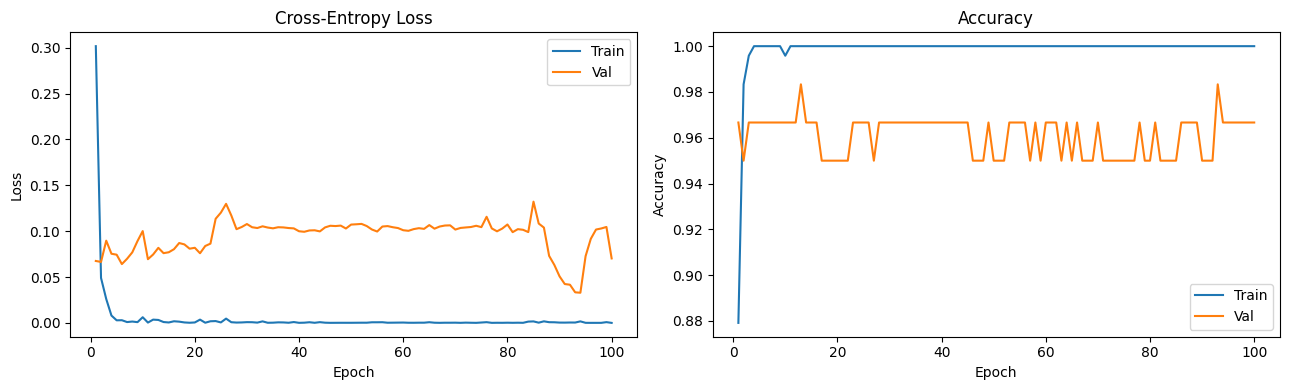

In [9]:
ep = range(1, len(train_losses)+1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(ep, train_losses, label='Train')
ax1.plot(ep, val_losses, label='Val')
ax1.set(xlabel='Epoch', ylabel='Loss', title='Cross-Entropy Loss')
ax1.legend()
ax2.plot(ep, train_accs, label='Train')
ax2.plot(ep, val_accs, label='Val')
ax2.set(xlabel='Epoch', ylabel='Accuracy', title='Accuracy')
ax2.legend()
plt.tight_layout()
plt.show()

## 9. Confusion Matrix


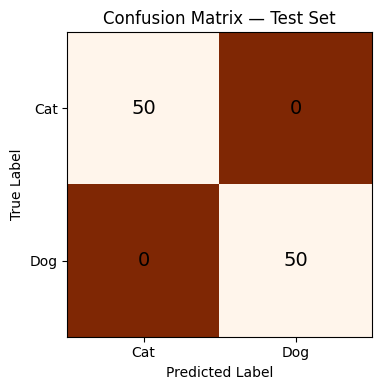

  Cat: 100.0%
  Dog: 100.0%


In [10]:
cnn_model.eval()
with torch.no_grad():
    preds_test = torch.argmax(cnn_model(tX_test), dim=1).numpy()
true_test = ty_test.numpy()
cm = np.zeros((2,2), dtype=int)
for t, p in zip(true_test, preds_test):
    cm[t][p] += 1
fig, ax = plt.subplots(figsize=(5,4))
ax.imshow(cm, cmap='Oranges_r')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=14)
ax.set_xticks([0,1]); ax.set_xticklabels(['Cat','Dog'])
ax.set_yticks([0,1]); ax.set_yticklabels(['Cat','Dog'])
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()
for i, cls in enumerate(['Cat','Dog']):
    ca = cm[i,i]/cm[i].sum() if cm[i].sum()>0 else 0
    print(f'  {cls}: {ca*100:.1f}%')

## 10. Prediction Grid


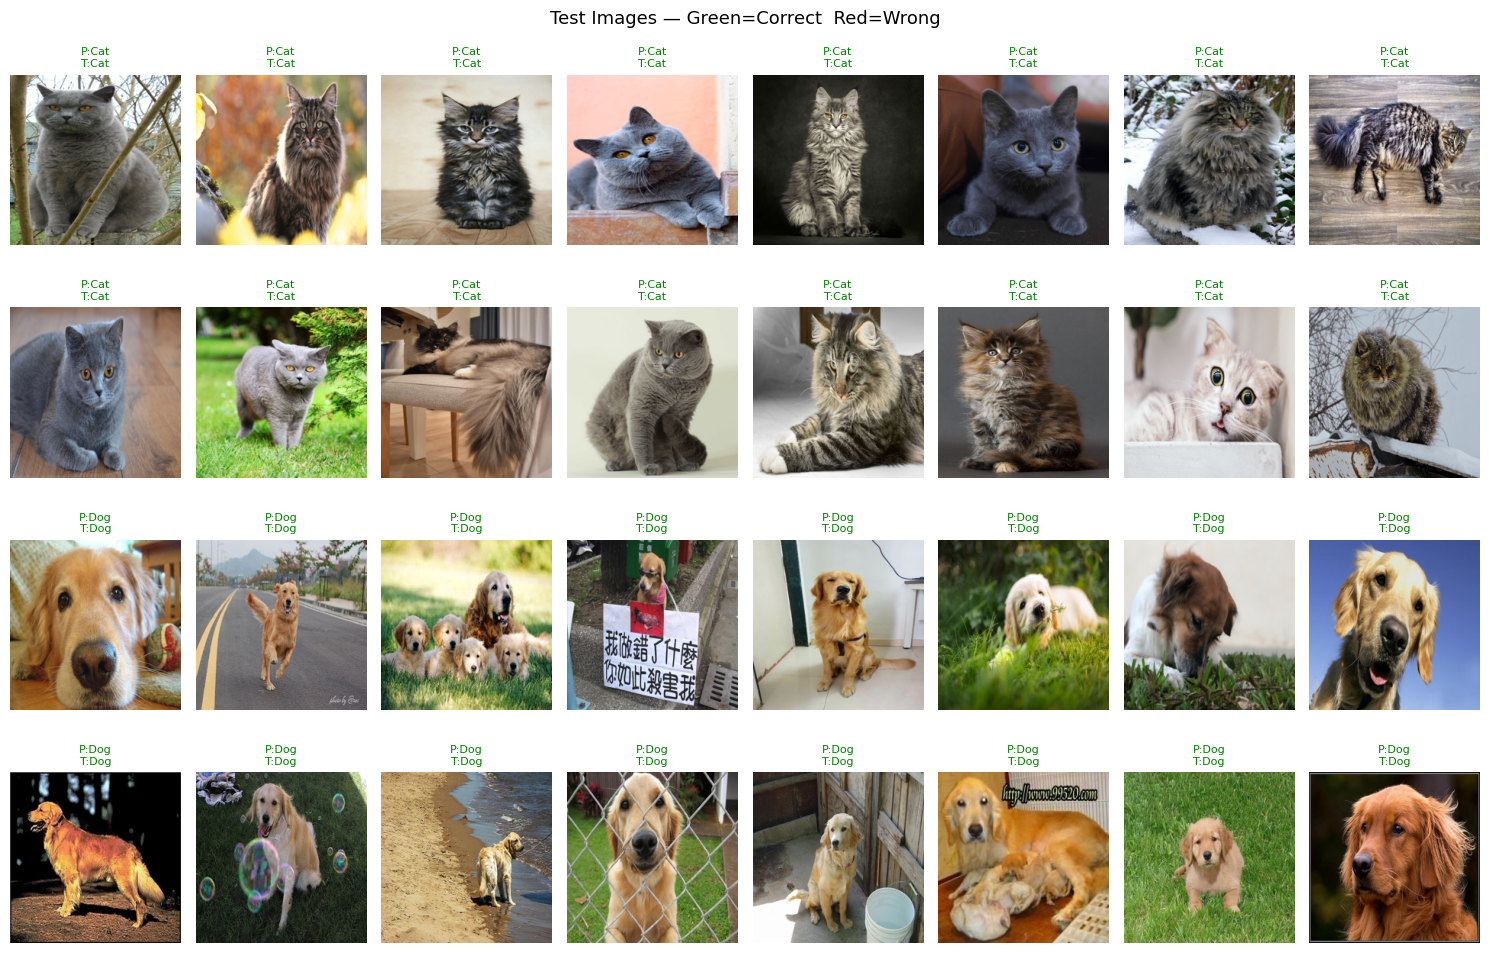

In [11]:
fig, axes = plt.subplots(4, 8, figsize=(15, 10))
axes = axes.flatten()
cnn_model.eval()
with torch.no_grad():
    preds_test = torch.argmax(cnn_model(tX_test), dim=1).numpy()
classes = ['Cat', 'Dog']
cat_idx = np.where(y_test == 0)[0][:16]
dog_idx = np.where(y_test == 1)[0][:16]
selected = np.concatenate([cat_idx, dog_idx])
for i, idx in enumerate(selected):
    img = X_test[idx].transpose(1, 2, 0) * std + mean
    axes[i].imshow(img.clip(0, 1))
    pred = classes[preds_test[idx]]
    true = classes[y_test[idx]]
    color = 'green' if pred == true else 'red'
    axes[i].set_title(f'P:{pred}\nT:{true}', color=color, fontsize=8)
    axes[i].axis('off')
plt.suptitle('Test Images — Green=Correct  Red=Wrong', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Save Model

In [12]:
torch.save(cnn_model.state_dict(), 'catdog_cnn_weights.pth')
print('Saved: catdog_cnn_weights.pth')

Saved: catdog_cnn_weights.pth
